In [1]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.cm as color
better_magma = color.magma
better_magma.set_bad('black',1.)
import matplotlib.colors as c

from prysm import (
    mathops, 
    conf,
)
from prysm.mathops import (
    _np,
    np,
    fft,
    interpolate,
    ndimage,
)
from prysm.coordinates import (
    make_xy_grid, 
    cart_to_polar,
)
from prysm.propagation import Wavefront as WF
from prysm.propagation import (
    focus_fixed_sampling,
    focus_fixed_sampling_backprop
)                              
from prysm.thinlens import (
    defocus_to_image_displacement,
    image_displacement_to_defocus,
)
from prysm.geometry import (
    offset_circle,
    circle,
    spider,
    gaussian,
)
from prysm.polynomials import (
    lstsq,
    noll_to_nm,
    zernike_nm,
    zernike_nm_seq,
    hopkins,
    sum_of_2d_modes,
    sum_of_2d_modes_backprop
)
mathops.set_backend_to_cupy()
# conf.config.precision = 32

from astropy.io import (
    fits,
    ascii,
)

from skimage.measure import centroid

import copy

from algos import BING_BONG, FFPR2, PDPR, model, mean_squared_error, gain_invariant_error
import utils

from functools import partial

from lina.utils import TikhonovInverse

import config_um
import config_um_wcc
from Batoid4LOFT.LAZULI_STOP_mark11 import Lazuli_stop, readBulkMotion, readDeformation

from psd_utils import PSDUtils

from scipy.optimize import minimize

from scipy.interpolate import RegularGridInterpolator

from tqdm import tqdm

from psd_utils import PSDUtils

from model import telescope
# from algos import pdpr, OPD, ADPR
import utils

from functools import partial

from opt import F77LBFGSB, runN, RAdam
from IPython.display import clear_output

# logging stuff
import logging
psd_log = logging.getLogger('__psd_utils__')
psd_log.disabled = True

%reload_ext autoreload
%autoreload 2
%matplotlib inline

import toml

## isolating snr/rms opd

In [32]:
data1 = utils.load_pickle('/home/derbyk/src/ffpr/sim_results/20260504_mc_misalignments_15mag_dec_50um_tilt_5as.pkl')
data2 = utils.load_pickle('/home/derbyk/src/ffpr/sim_results/20260504_mc_misalignments_17mag_dec_50um_tilt_5as.pkl')
data3 = utils.load_pickle('/home/derbyk/src/ffpr/sim_results/20260504_mc_misalignments_19mag_dec_50um_tilt_5as.pkl')

median_rms_truth = np.zeros(len(data1) * 3)
median_rms_residual = np.zeros(len(data1) * 3)
max_rms_residual = np.zeros(len(data1) * 3)
min_rms_residual = np.zeros(len(data1) * 3)
std_rms_residual = np.zeros(len(data1) * 3)
median_snr = np.zeros(len(data1) * 3)

data = data1
for i, case in enumerate(data):
    median_rms_truth[i] = np.median(np.array(data[case]['RMS_TRUTH_PER_FIELD']))
    median_rms_residual[i] = np.median(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    max_rms_residual[i] = np.max(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    min_rms_residual[i] = np.min(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    std_rms_residual[i] = np.std(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    median_snr[i] = np.median(np.array(data[case]['SNR_PER_FIELD']))

data = data2
for i, case in enumerate(data):
    i += 100
    median_rms_truth[i] = np.median(np.array(data[case]['RMS_TRUTH_PER_FIELD']))
    median_rms_residual[i] = np.median(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    max_rms_residual[i] = np.max(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    min_rms_residual[i] = np.min(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    std_rms_residual[i] = np.std(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    median_snr[i] = np.median(np.array(data[case]['SNR_PER_FIELD']))

data = data3
for i, case in enumerate(data):
    i += 200
    median_rms_truth[i] = np.median(np.array(data[case]['RMS_TRUTH_PER_FIELD']))
    median_rms_residual[i] = np.median(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    max_rms_residual[i] = np.max(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    min_rms_residual[i] = np.min(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    std_rms_residual[i] = np.std(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    median_snr[i] = np.median(np.array(data[case]['SNR_PER_FIELD']))

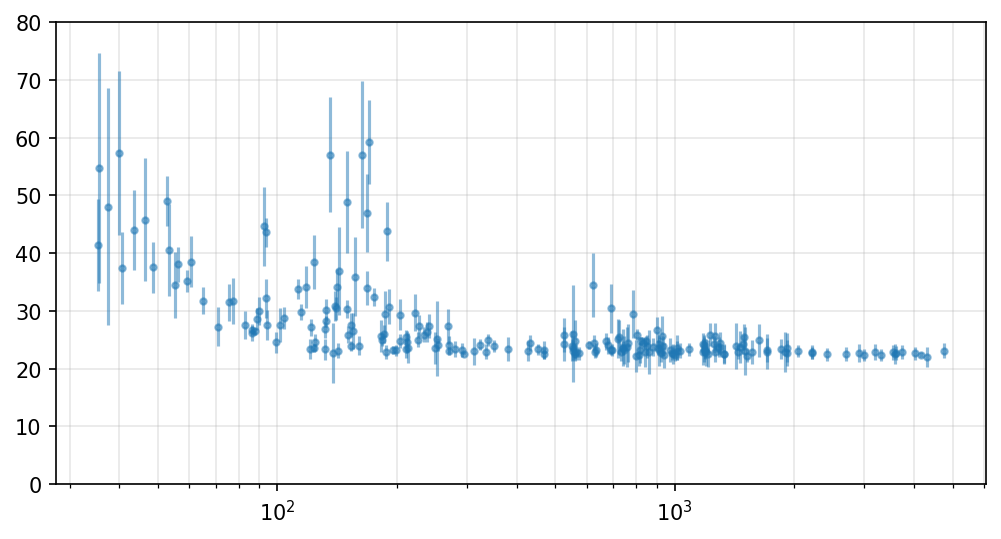

In [27]:
fails_x = []
x = []
y = []
e = []
for i in range(len(median_snr)):
    if median_rms_residual[i] < 62.5:
        y.append(float(median_rms_residual[i]))
        x.append(float(median_snr[i]))
        e.append(float(std_rms_residual[i]))
    else:
        fails_x.append(float(median_snr[i]))

fails_x = _np.array(fails_x)
x = _np.array(x)
y = _np.array(y)

plt.figure(figsize=(8, 4), dpi=150)
plt.errorbar(x, y, e, linestyle='none', marker='.', alpha=0.5)
plt.xscale('log')
plt.ylim([0, 80])
plt.grid(which='both', alpha=0.3)

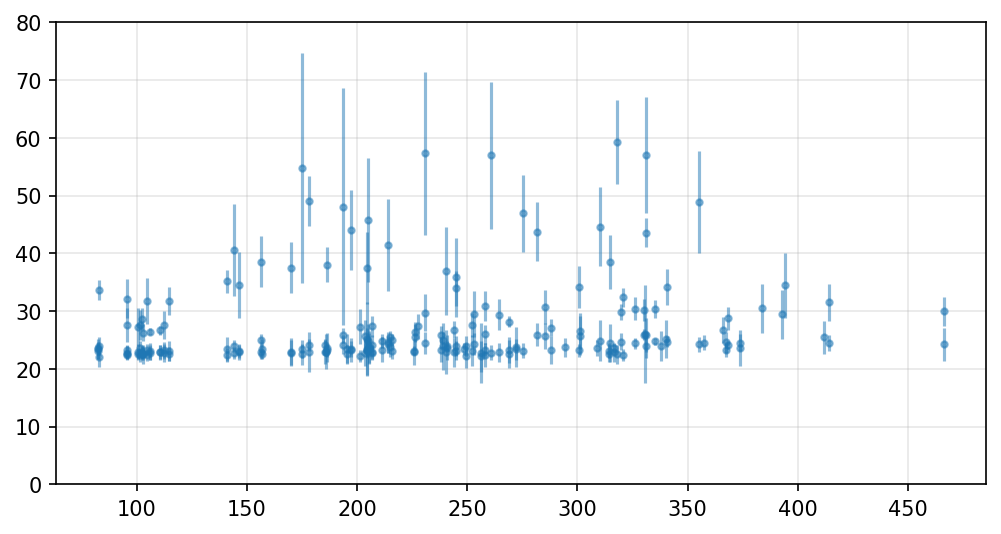

In [29]:
fails_x = []
x = []
y = []
e = []
for i in range(len(median_rms_truth)):
    if median_rms_residual[i] < 62.5:
        y.append(float(median_rms_residual[i]))
        x.append(float(median_rms_truth[i]))
        e.append(float(std_rms_residual[i]))
    else:
        fails_x.append(float(median_rms_truth[i]))

fails_x = _np.array(fails_x)
x = _np.array(x)
y = _np.array(y)

plt.figure(figsize=(8, 4), dpi=150)
plt.errorbar(x, y, e, linestyle='none', marker='.', alpha=0.5)
plt.ylim([0, 80])
plt.grid(which='both', alpha=0.3)

/tmp/ipykernel_912191/3685419893.py:96: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim([ymin , ymax ])
/tmp/ipykernel_912191/3685419893.py:119: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim([ymin , ymax ])


Text(0.5, 0.98, 'RMag 15, 17, and 19 Combined\n100 Misalignment Cases; 70% Convergence Rate\n$\\pm25\\mu m$ Decenter X, Y; $\\pm2.5$" Tilt X, Y')

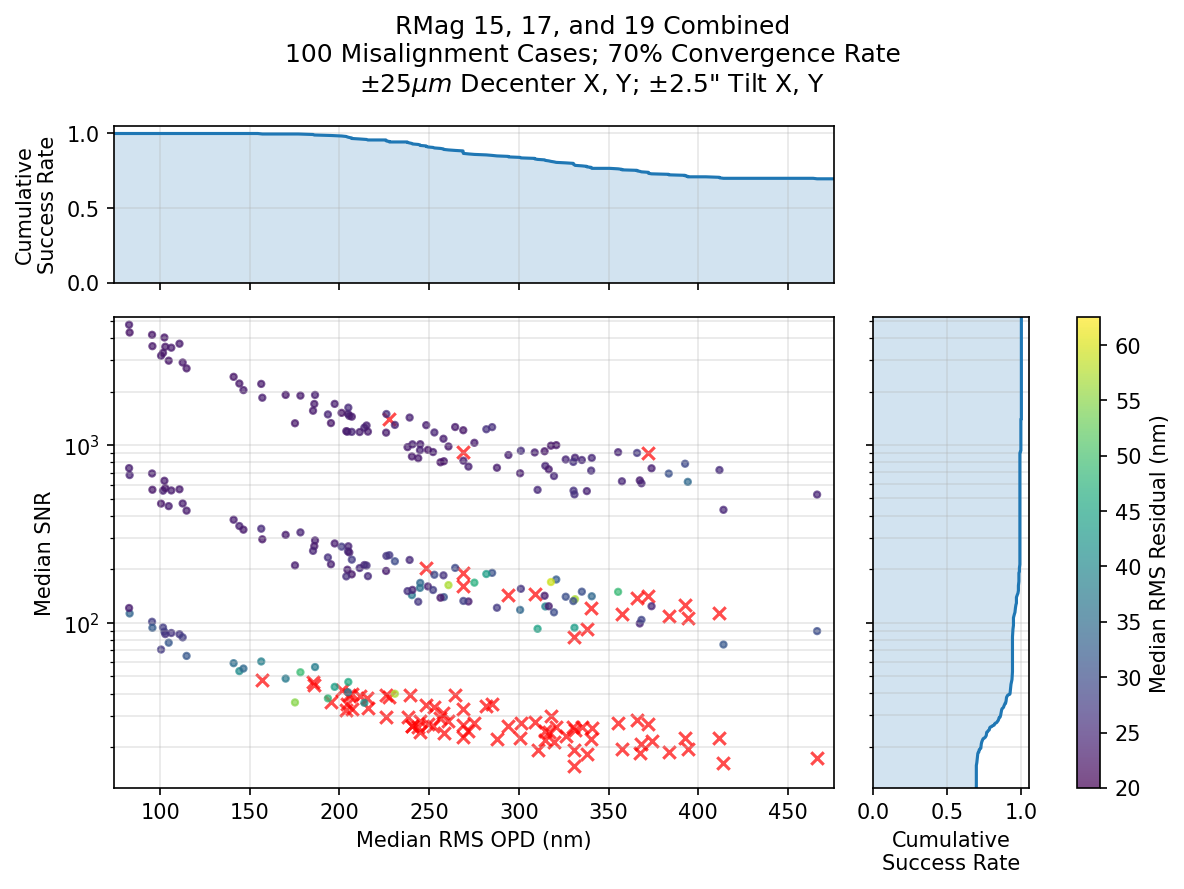

In [61]:
fig, axs = plt.subplot_mosaic([['histx', 'poop'],
                               ['scatter', 'histy']],
                               figsize=(8, 6), 
                               height_ratios=[1, 3],
                               width_ratios=[3, 1],
                               layout='tight',
                               dpi=150)

count = 0
fails_x = []
fails_y = []
xs = []
ys = []
cs = []

for x, y, c in zip(median_rms_truth, median_snr, median_rms_residual):
    if c < 62.5:
        xs.append(float(x))
        ys.append(float(y))
        cs.append(float(c))
    else:
        fails_x.append(float(x))
        fails_y.append(float(y))

xs = _np.array(xs)
ys = _np.array(ys)
cs = _np.array(cs)
fails_x = _np.array(fails_x)
fails_y = _np.array(fails_y)

xmin = _np.array([xs.min(), fails_x.min()]).min() * 0.9
xmax = _np.array([xs.max(), fails_x.max()]).max() * 1.02

ymin = _np.array([ys.min(), fails_y.min()]).min() * 0.
ymax = _np.array([ys.max(), fails_y.max()]).max() * 1.1

cmin = 20
cmax = 62.5

sorted_fails_x = sorted(fails_x)
cdf_opd = [1]
cdf_x = [xmin ]
x = xmin
count = 0
while x < xmax:
    if count == len(fails_x):
        x += 10
        break
    if x + 10 < sorted_fails_x[count]:
        x += 10
        cdf_x.append(x)
        cdf_opd.append(cdf_opd[-1])
    else:
        x = sorted_fails_x[count]
        cdf_x.append(x)
        cdf_opd.append((1 - ((count + 1) / 300)))
        count += 1
cdf_x.append(xmax )
cdf_opd.append(cdf_opd[-1])
cdf_opd = _np.array(cdf_opd)
cdf_x = _np.array(cdf_x)

sorted_fails_y = _np.flip(sorted(fails_y))
cdf_snr = [1]
cdf_y = [ymax ]
y = ymax
count = 0
while y > ymin:
    if count == len(fails_y):
        y -= 10
        break
    if y - 10 > sorted_fails_y[count]:
        y -= 10
        cdf_y.append(y)
        cdf_snr.append(cdf_snr[-1])
    else:
        y = sorted_fails_y[count]
        cdf_y.append(y)
        cdf_snr.append((1 - ((count + 1) / 300)))
        count += 1
cdf_y.append(ymin )
cdf_snr.append(cdf_snr[-1])
cdf_snr = _np.array(cdf_snr)
cdf_y = _np.array(cdf_y)

axs['poop'].set_axis_off()

ax = axs['scatter']
ax.scatter(fails_x, fails_y, c='r', alpha=0.7, marker='x')
ax.set_yscale('log')
s = ax.scatter(xs, ys, c=cs, alpha=0.7, marker='.')
s.set_clim([cmin, cmax])
ax.set_xlabel('Median RMS OPD (nm)')
ax.set_ylabel('Median SNR')
ax.set_xlim([xmin , xmax ])
ax.set_ylim([ymin , ymax ])
ax.grid(which='both', alpha=0.3)

plt.colorbar(s, ax=axs['histy'], pad=0.2, label='Median RMS Residual (nm)')

ax = axs['histx']
ax.plot(cdf_x, cdf_opd)
ax.fill_between(cdf_x, cdf_opd, alpha=0.2)
# ax.hist(np.array(fails_x).get(), bins=40, color='r')
ax.tick_params(axis='x', labelbottom=False)
ax.set_ylabel('Cumulative\nSuccess Rate')
ax.set_xlim([xmin , xmax ])
ax.set_ylim([0, 1.05])
ax.grid(which='both', alpha=0.3)

ax = axs['histy']
ax.plot(cdf_snr, cdf_y,)
ax.fill_betweenx(cdf_y, cdf_snr, alpha=0.2)
ax.set_yscale('log')
# ax.hist(np.array(fails_y).get(), bins=20, color='r', orientation='horizontal')
ax.tick_params(axis='y', labelleft=False)
ax.set_xticks([0, 0.5, 1])
ax.set_xlabel('Cumulative\nSuccess Rate')
ax.set_ylim([ymin , ymax ])
ax.set_xlim([0, 1.05])
ax.grid(which='both', alpha=0.3)


fig.suptitle(f'RMag 15, 17, and 19 Combined\n{len(data):02.0f} Misalignment Cases; {len(cs) / 300 * 100:02.0f}% Convergence Rate\n$\pm25\mu m$ Decenter X, Y; $\pm2.5$" Tilt X, Y')
